<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 60 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Crop Yield by Fertilizer: F &amp; ANOVA 🌾</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">A t-test compares two means. To compare FOUR fertilizers at once we need ANOVA, which splits the total variance into between-group and within-group pieces and forms the F-ratio. Then Tukey tells us exactly which fertilizers differ.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, itertools
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/agricultural_yield_optimization.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"agricultural_yield_optimization.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 4)


,plot_id,soil_ph,fertilizer_type,crop_yield_bushels
0,PLOT_6000,6.69,Fertilizer_B,49.09
1,PLOT_6001,6.95,Fertilizer_D,50.27
2,PLOT_6002,7.32,Fertilizer_D,49.43
3,PLOT_6003,6.83,Fertilizer_A,51.77
4,PLOT_6004,6.42,Fertilizer_B,49.49


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · FOUR GROUPS, FOUR MEANS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Look at the yields before testing</div>
<div style="color:#4a5578;margin-top:6px">Each of 1,000 plots got one of four fertilizers and reported its crop_yield_bushels. We group by fertilizer and look at the means and spread, the question is whether the gaps between groups are bigger than the noise within them.</div>
</div>

In [2]:
g = "fertilizer_type"; y = "crop_yield_bushels"
summary = df.groupby(g)[y].agg(["count","mean","std"]).round(2)
print(summary)
print(f"\ngrand mean = {df[y].mean():.2f} bushels")

                 count   mean   std
fertilizer_type                    
Fertilizer_A       257  49.62  5.03
Fertilizer_B       250  52.50  5.44
Fertilizer_C       266  48.34  4.72
Fertilizer_D       227  54.86  5.35

grand mean = 51.19 bushels


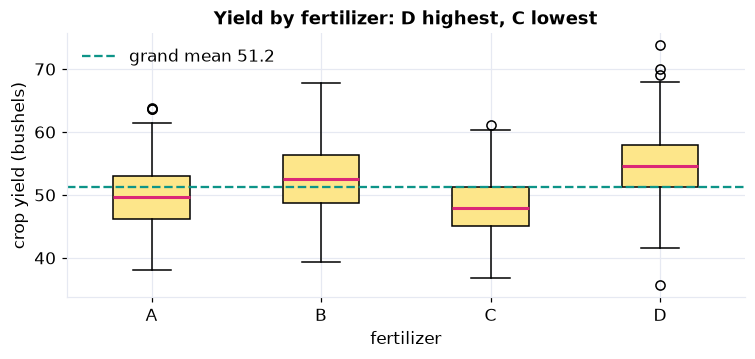

In [3]:
order = sorted(df[g].unique())
data = [df[df[g]==t][y].values for t in order]
fig,ax=plt.subplots(figsize=(7,3.4))
bp=ax.boxplot(data,tick_labels=[t.replace("Fertilizer_","") for t in order],patch_artist=True,
              boxprops=dict(facecolor="#fde68a"),medianprops=dict(color=PINK,linewidth=2))
ax.axhline(df[y].mean(),color=TEAL,ls="--",lw=1.5,label=f"grand mean {df[y].mean():.1f}")
ax.set_xlabel("fertilizer"); ax.set_ylabel("crop yield (bushels)"); ax.set_title("Yield by fertilizer: D highest, C lowest"); ax.legend()
plt.tight_layout(); plt.show()

The group means range from **48.3** bushels (Fertilizer C) to **54.9** (Fertilizer D), a spread of more than 6 bushels, while each group's own scatter is about 5 bushels. The between-group gaps look larger than the within-group noise, which is exactly what ANOVA quantifies.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · PARTITION THE VARIANCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Between-group vs within-group</div>
<div style="color:#4a5578;margin-top:6px">ANOVA splits the total variation into SSB (how far group means sit from the grand mean) and SSW (scatter inside each group). The F-ratio is MSB/MSW, big when groups differ more than chance allows.</div>
</div>

In [4]:
grand = df[y].mean(); N=len(df); k=df[g].nunique()
groups = {t:df[df[g]==t][y].values for t in order}
SSB = sum(len(v)*(v.mean()-grand)**2 for v in groups.values())
SSW = sum(((v-v.mean())**2).sum() for v in groups.values())
dfb, dfw = k-1, N-k
MSB, MSW = SSB/dfb, SSW/dfw
F_manual = MSB/MSW
print(f"SSB = {SSB:8.1f}   dfb = {dfb:3d}   MSB = {MSB:8.2f}")
print(f"SSW = {SSW:8.1f}   dfw = {dfw:3d}   MSW = {MSW:8.2f}")
print(f"F = MSB/MSW = {F_manual:.2f}")
# scipy one-liner agrees
F, p = stats.f_oneway(*data)
print(f"\nscipy f_oneway: F = {F:.2f},  p-value = {p:.3e}")
print(f"eta-squared (variance explained) = {SSB/(SSB+SSW):.3f}")

SSB =   6264.8   dfb =   3   MSB =  2088.28
SSW =  26201.1   dfw = 996   MSW =    26.31
F = MSB/MSW = 79.38

scipy f_oneway: F = 79.38,  p-value = 4.765e-46
eta-squared (variance explained) = 0.193


The F-statistic is **79.4** on (3, 996) degrees of freedom, with p &#8776; 10<sup>&#8722;46</sup>. Under H<sub>0</sub> (all fertilizers equal) F would hover near 1; a value of 79 is astronomically unlikely by chance, so at least one fertilizer differs. The **&#951;&#178; &#8776; 0.19** says fertilizer choice explains about 19% of the variation in yield, the rest is plot-to-plot noise.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · WHICH ONES DIFFER? TUKEY HSD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">ANOVA says 'some'; post-hoc says 'which'</div>
<div style="color:#4a5578;margin-top:6px">A significant F only says the means are not all equal. Tukey's Honest Significant Difference compares every pair while controlling the family-wide error rate, so we can rank the fertilizers safely.</div>
</div>

In [5]:
qcrit = stats.studentized_range.ppf(0.95, k, dfw)
print(f"Tukey q critical (k={k}, df={dfw}, alpha=0.05) = {qcrit:.3f}\n")
for a,b in itertools.combinations(order,2):
    na,nb = len(groups[a]),len(groups[b])
    se = np.sqrt(MSW/2*(1/na+1/nb))
    diff = groups[a].mean()-groups[b].mean()
    q = abs(diff)/se
    verdict = "SIGNIFICANT" if q>qcrit else "not sig"
    print(f"{a[-1]} vs {b[-1]}: mean diff = {diff:+5.2f}, q = {q:5.2f}  -> {verdict}")

Tukey q critical (k=4, df=996, alpha=0.05) = 3.639

A vs B: mean diff = -2.88, q =  8.92  -> SIGNIFICANT
A vs C: mean diff = +1.28, q =  4.03  -> SIGNIFICANT
A vs D: mean diff = -5.23, q = 15.84  -> SIGNIFICANT
B vs C: mean diff = +4.15, q = 13.00  -> SIGNIFICANT
B vs D: mean diff = -2.36, q =  7.09  -> SIGNIFICANT
C vs D: mean diff = -6.51, q = 19.87  -> SIGNIFICANT


Every one of the six pairwise comparisons clears the Tukey threshold (q > 3.64), so the full ranking is real: **D (54.9) &gt; B (52.5) &gt; A (49.6) &gt; C (48.3)**. Fertilizer **D** is the clear winner, beating the worst performer C by more than 6 bushels a plot. Tukey keeps this honest: testing all six pairs with naive t-tests would inflate the false-positive rate, while the studentized-range adjustment holds the family-wide error at 5%.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed &mdash; and Part IX complete</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">ANOVA compares many means at once by partitioning variance: F = MSB/MSW = 79.4 (p &#8776; 10<sup>&#8722;46</sup>) proves the fertilizers are not all equal, and Tukey HSD ranks them D &gt; B &gt; A &gt; C with every pair significant. This closes our tour of the distributions, from Bernoulli trials to the F-ratio. The same engine, the Central Limit Theorem, underlies the t, chi-square, and F tests alike, and carries us straight into statistical inference.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>